# Sinhala→English NMT Hallucination Dataset Generation

This notebook constructs the synthetic hallucination dataset used to train the token-level detectors in this project. Starting from the `NLPC-UOM/nllb-top25k-ensi-cleaned` corpus, it generates four negative (hallucinated) samples per ground-truth sentence pair using a **five-strategy corruption pipeline**, then applies semantic and grammatical filtering to ensure training examples are realistic and challenging.

- **Corruption strategies** — NER swap, semantic drift, dependency swap, numeric distortion, and high-temperature NLLB sampling
- **Semantic filter** — BERTScore F1 threshold of 0.85 to discard outputs that are valid paraphrases rather than genuine hallucinations
- **Grammar filter** — LanguageTool post-hoc check to revert hypotheses with more than two meaningful grammar errors, keeping surface form plausible
- **Class balancing** — the majority class is downsampled to produce a perfectly balanced 50/50 split for training

---

## Table of Contents

1. [Environment Setup & Dependencies](#1-environment-setup--dependencies)
2. [Grammar Checker & BERTScore Setup](#2-grammar-checker--bertscore-setup)
3. [BERTScore Distribution Visualiser](#3-bertscore-distribution-visualiser)
4. [Grammar Checker Initialisation](#4-grammar-checker-initialisation)
5. [Load & Clean Source Dataset](#5-load--clean-source-dataset)
6. [Load Base Translation Model (NLLB)](#6-load-base-translation-model-nllb)
7. [Hallucination Generator Class](#7-hallucination-generator-class)
8. [Execute Dataset Generation Pipeline](#8-execute-dataset-generation-pipeline)
9. [Save Full Dataset](#9-save-full-dataset)
10. [Balance Dataset & Export](#10-balance-dataset--export)
11. [Grammar Validity Filter](#11-grammar-validity-filter)
12. [Save Grammar-Checked Dataset](#12-save-grammar-checked-dataset)


In [1]:
!pip install -q transformers datasets accelerate pandas sacremoses spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 12.6 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.8 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Grammar Checker & BERTScore Setup

Install `language_tool_python` for grammar validation and `bert_score` for the semantic filtering step applied to high-temperature outputs. Both are kept as a separate installation cell as they introduce heavier dependencies and may require a kernel restart if they conflict with the base environment.


In [2]:
# Grammar-check dependency
!pip install -q language_tool_python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 1.6 MB/s eta 0:00:00


In [8]:
!pip install -q bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00


## 3. BERTScore Distribution Visualiser

Define a helper function that plots the distribution of BERTScore F1 values for high-temperature generated hypotheses. The chart shades the region below the `0.85` semantic filter threshold to make it immediately clear which proportion of samples will be retained versus discarded and sent to a fallback deterministic strategy.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_bertscore_distribution(f1_scores, threshold=0.85):
    """
    Generates a distribution plot of BERTScores with threshold shading.
    """
    sns.set_theme(style="whitegrid")
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Plot the distribution
    sns.kdeplot(f1_scores, fill=True, color="gray", alpha=0.3)
    sns.histplot(f1_scores, bins=30, color="skyblue", edgecolor='white', alpha=0.7, stat="density")
    
    # Add threshold line
    plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
    
    # Add Shading
    # Retained = Hallucinations (Low similarity)
    plt.axvspan(min(f1_scores)-0.05, threshold, color='red', alpha=0.1, label='Retained (Hallucination)')
    # Rejected = Paraphrases (High similarity)
    plt.axvspan(threshold, 1.05, color='green', alpha=0.1, label='Rejected (Paraphrase)')
    
    # Labels
    plt.title("BERTScore F1 Distribution for High-Temperature Outputs ($T=1.5$)", fontsize=14)
    plt.xlabel("BERTScore F1 (Relative to Reference)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.xlim(min(f1_scores)-0.05, 1.0)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig("bertscore_distribution.png", dpi=300)
    print("Chart saved as bertscore_distribution.png")

## 4. Grammar Checker Initialisation

Set up a local LanguageTool instance for post-hoc grammar validation. Grammar checking is applied after semantic corruption so that the detector is trained to identify semantic errors rather than surface-level syntactic breakage — synthetic hallucinations must be grammatically plausible even when semantically wrong.


In [ ]:
import language_tool_python

class GrammarChecker:
    """
    Lightweight wrapper around LanguageTool (offline) that decides whether
    a sentence is 'grammatically acceptable' for dataset inclusion.

    A sentence is rejected if it has more than `max_errors` grammar/style
    errors after ignoring punctuation-only and whitespace rules, which are
    too noisy for machine-generated text.

    """

    # LanguageTool rule categories we want to IGNORE
    _IGNORE_CATEGORIES = {
        "PUNCTUATION",
        "TYPOGRAPHY",
        "WHITESPACE",
        "CASING",        # NER swaps can change casing legitimately
    }

    def __init__(self, max_errors: int = 2, language: str = "en-US"):
        print("Loading LanguageTool grammar checker (first run downloads ~200 MB)...")
        self.tool = language_tool_python.LanguageTool(language)
        self.max_errors = max_errors
        print("GrammarChecker ready.")

    def _filter_matches(self, matches):
        # Remove noisy rule categories from LanguageTool match list.
        return [
            m for m in matches
            if m.category.upper() not in self._IGNORE_CATEGORIES
        ]

    def is_grammatically_valid(self, text: str) -> bool:

        # Returns True if the sentence has <= max_errors meaningful grammar errors.

        if not text or not text.strip():
            return False
        matches = self.tool.check(text)
        significant_errors = self._filter_matches(matches)
        return len(significant_errors) <= self.max_errors

    def error_count(self, text: str) -> int:
        # Returns the number of meaningful grammar errors in text.
        matches = self.tool.check(text)
        return len(self._filter_matches(matches))


grammar_checker = GrammarChecker(max_errors=2)

# Quick test
_tests = [
    ("The Prime Minister visited Kandy on Tuesday.", True),   
    ("Minister The visited on Kandy Tuesday Prime.", False),  
    ("She go to the school yesterday.", False),               
]
print("\nGrammar checker sanity tests:")
for sent, expected in _tests:
    result = grammar_checker.is_grammatically_valid(sent)
    status = "✓" if result == expected else "✗"
    print(f"  {status} [{result}] '{sent}'")


Loading LanguageTool grammar checker (first run downloads ~200 MB)...


GrammarChecker ready.

Grammar checker sanity tests:
  ✓ [True] 'The Prime Minister visited Kandy on Tuesday.'
  ✗ [True] 'Minister The visited on Kandy Tuesday Prime.'
  ✗ [True] 'She go to the school yesterday.'


## 5. Load & Clean Source Dataset

Load the `NLPC-UOM/nllb-top25k-ensi-cleaned` Sinhala-English corpus and apply a two-stage cleaning pipeline before sampling:

1. Drop rows where the English target contains Sinhala Unicode characters — these indicate encoding failures rather than valid translations.
2. Drop rows where the English target contains no Latin characters — a catch-all for empty or script-mismatched outputs.


In [5]:
import pandas as pd
import re
from datasets import load_dataset

# 1. Load the NLPC-UOM cleaned dataset
print("Loading NLPC-UOM/nllb-top25k-ensi-cleaned...")
dataset = load_dataset("NLPC-UOM/nllb-top25k-ensi-cleaned", split="train")

# 2. Convert to Pandas
df = pd.DataFrame(dataset)

# 3. Rename columns to match your preferred format
# Mapping: SI_sentence -> sinhala, EN_sentence -> english
df.rename(columns={
    'SI_sentence': 'sinhala', 
    'EN_sentence': 'english'
}, inplace=True)

# --- CLEANING STEP START ---
print(f"Original Row Count: {len(df)}")

def is_valid_english(text):
    """
    Returns True only if:
    1. The text DOES NOT contain Sinhala characters (Unicode range \u0D80-\u0DFF).
    2. The text DOES contain at least one English letter (a-z, A-Z).
    """
    s = str(text)
    # Check for Sinhala characters
    if re.search(r'[\u0D80-\u0DFF]', s):
        return False
    # Check for at least one English letter (avoids numbers/punctuation only rows)
    if not re.search(r'[a-zA-Z]', s):
        return False
    return True

# Apply filtering
df = df[df['english'].apply(is_valid_english)].copy()
print(f"Cleaned Row Count: {len(df)} (Removed mixed/invalid rows)")
# --- CLEANING STEP END ---

# 4. Take a sample of 5000 rows from the CLEANED data
# We use reset_index so the indices start fresh from 0
df_sample = df.sample(n=7500, random_state=42).reset_index(drop=True)

print(f"Final Sample Size: {len(df_sample)}")
print("Columns found:", df_sample.columns.tolist())
display(df_sample.head())

Loading NLPC-UOM/nllb-top25k-ensi-cleaned...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Original Row Count: 25000
Cleaned Row Count: 24996 (Removed mixed/invalid rows)
Final Sample Size: 7500
Columns found: ['english', 'sinhala', 'cosine_similarity']


,english,sinhala,cosine_similarity
0,"Nowadays, you do not call them miracles.","වර්තමානයේ, ඔබ ඒවා ප්‍රාතිහාර්යයන් ලෙස නොකියයි.",0.868030
1,And their son is an exact replica of his father.,ඒ වගේම ඔවුන්ගේ පුතා ඔහුගේ පියාගේම අනුරුවකි.,0.781679
2,Trust us and you will get more.,"අපව විශ්වාස කරන්න, එවිට ඔබට තවත් වාසි ලැබෙනු ඇත.",0.851481
3,"Channel-tag, together with the world!","නාලිකා පාඨය, ලෝකය සමඟ එක්ව!",0.802776
4,It is the beast that we promised you.,අපි ඔබට පොරොන්දු වූ සත්ත්වයා මොහු යි.,0.792051


## 6. Load Base Translation Model (NLLB)

Load `facebook/nllb-200-1.3B` and its tokeniser into GPU memory. This model is used exclusively for the **high-temperature stochastic generation** strategy, where ground-truth sentences are re-encoded at temperature `T=1.5` with nucleus sampling to produce fluent but semantically divergent hypotheses.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Setup Device 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Load the NLLB Model and Tokenizer
model_checkpoint = "facebook/nllb-200-distilled-1.3B"

print(f"Loading model: {model_checkpoint} (this might take a minute)...")

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint,
                                             torch_dtype=torch.float16).to(device)

print("Model and Tokenizer loaded successfully.")



Using device: cuda
Loading model: facebook/nllb-200-distilled-1.3B (this might take a minute)...


config.json:   0%|          | 0.00/808 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/5.48G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model and Tokenizer loaded successfully.


## 7. Hallucination Generator Class

Define the `HallucinationGenerator` class, which implements all five corruption strategies. Each strategy is designed to produce a distinct failure mode that mirrors real NMT hallucination patterns:

- **NER swap** — replaces named entities with same-category alternatives drawn from a pre-built entity pool, causing factual substitution errors
- **Semantic drift** — substitutes a content word with its WordNet antonym, reversing or distorting the sentence's intended meaning
- **Dependency swap** — transposes the syntactic subject and object using spaCy's dependency parse, producing agent/patient confusion
- **Numeric distortion** — increments, decrements, or repeats digits with magnitude proportional to the original value, targeting numerical faithfulness
- **High-temperature sampling** — re-encodes ground-truth sentences through NLLB-1.3B at `T=1.5` with nucleus sampling to generate fluent but semantically divergent outputs


In [ ]:
import spacy
import random
import re
import nltk
import torch
from collections import defaultdict
from typing import List, Dict, Tuple


try:
    from nltk.corpus import wordnet
except ImportError:
    import nltk
    nltk.download('wordnet')
    from nltk.corpus import wordnet


class HallucinationGenerator:
    def __init__(self, reference_sentences: List[str], model=None, tokenizer=None, device='cuda'):
        self.sentences = [str(s) for s in reference_sentences if str(s) != 'nan']
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        
        # --- Load Spacy ---
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except OSError:
            print("Downloading Spacy model...")
            from spacy.cli import download
            download("en_core_web_sm")
            self.nlp = spacy.load("en_core_web_sm")

        # --- Build Entity Pool ---
        print("Building Entity Pool for NER Swaps...")
        self.entity_pool = self._build_entity_pool()
        print(f"Ready. Entity Pool contains {sum(len(v) for v in self.entity_pool.values())} entities.")

    def _build_entity_pool(self) -> Dict[str, List[str]]:
        pool = defaultdict(list)
        sample_size = min(len(self.sentences), 2000) 
        for doc in self.nlp.pipe(random.sample(self.sentences, sample_size)):
            for ent in doc.ents:
                clean_text = ent.text.strip()
                if len(clean_text) > 1:
                    pool[ent.label_].append(clean_text)
        return pool

    def hallucinate_ner_swap(self, text: str, doc=None) -> str:
        if doc is None: doc = self.nlp(text)
        if not doc.ents: return text 
        target_ent = random.choice(doc.ents)
        label = target_ent.label_
        if label not in self.entity_pool or not self.entity_pool[label]: return text
        candidates = self.entity_pool[label]
        replacement = random.choice(candidates)
        if replacement == target_ent.text and len(candidates) > 1:
            replacement = random.choice(candidates)
        return text.replace(target_ent.text, replacement, 1)

    def hallucinate_semantic_swap(self, text: str, doc=None) -> str:
        # Semantic swap doesn't rely strictly on Spacy deps, so we just use the text
        words = text.split()
        if not words: return text
        for _ in range(3):
            target_idx = random.randint(0, len(words)-1)
            word = words[target_idx]
            antonyms = []
            for syn in wordnet.synsets(word):
                for lemma in syn.lemmas():
                    if lemma.antonyms():
                        antonyms.append(lemma.antonyms()[0].name())
            if antonyms:
                replacement = random.choice(antonyms)
                if word[0].isupper(): replacement = replacement.capitalize()
                words[target_idx] = replacement.replace('_', ' ')
                return " ".join(words)
        return text

    def hallucinate_dependency_swap(self, text: str, doc=None) -> str:
        if doc is None: doc = self.nlp(text)
        subj, obj = None, None
        for token in doc:
            if "subj" in token.dep_: subj = token
            if "obj" in token.dep_: obj = token
        if subj and obj and subj.text.lower() != obj.text.lower():
            placeholder = "___TEMP_SWAP___"
            temp_text = text.replace(subj.text, placeholder, 1)
            temp_text = temp_text.replace(obj.text, subj.text, 1)
            temp_text = temp_text.replace(placeholder, obj.text, 1)
            return temp_text
        return text

    def hallucinate_number_swap(self, text: str, doc=None) -> str:
        numbers = re.findall(r'\b\d+\b', text)
        if not numbers: return text
        target = random.choice(numbers)
        val = int(target)
        strategy = random.choice(['inc', 'dec', 'repeat'])
        if strategy == 'inc':
            new_val = val + random.randint(1, max(10, int(val*0.2)))
        elif strategy == 'dec':
            new_val = max(0, val - random.randint(1, max(10, int(val*0.2))))
        else:
            new_val = int(str(val) + str(random.randint(0,9)))
        return text.replace(target, str(new_val), 1)

    def _detect_applicable_strategies(self, text: str, doc=None) -> Tuple[List[callable], object]:
        """Returns applicable strategies AND the parsed doc to save future computation."""
        if doc is None: doc = self.nlp(text)
        strategies = []
        if doc.ents: strategies.append(self.hallucinate_ner_swap)
        if re.search(r'\b\d+\b', text): strategies.append(self.hallucinate_number_swap)
        if len(text.split()) > 4: strategies.append(self.hallucinate_semantic_swap)
        subj = any("subj" in t.dep_ for t in doc)
        obj = any("obj" in t.dep_ for t in doc)
        if subj and obj: strategies.append(self.hallucinate_dependency_swap)
        return strategies, doc

# --- BATCHED GPU GENERATION ---
    def hallucinate_high_temp_batch(self, texts: List[str], temperature: float = 1.5, batch_size: int = 32) -> List[str]:
        """Processes a list of sentences through the LLM all at once."""
        from tqdm.auto import tqdm 
        
        if not self.model or not self.tokenizer or not texts: 
            return texts
            
        results = []
        forced_bos_token_id = self.tokenizer.convert_tokens_to_ids("eng_Latn")
        
        for i in tqdm(range(0, len(texts), batch_size), desc="GPU Batch Generation"):
            batch = texts[i:i+batch_size]
            inputs = self.tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(self.device)
            
            gen_kwargs = {
                "do_sample": True, "temperature": temperature, "top_k": 50, "top_p": 0.95, 
                "max_length": 128, "forced_bos_token_id": forced_bos_token_id 
            }
            
            with torch.no_grad(): # Saves memory during generation
                outputs = self.model.generate(**inputs, **gen_kwargs)
                
            results.extend(self.tokenizer.batch_decode(outputs, skip_special_tokens=True))
            
        return results

## 8. Execute Dataset Generation Pipeline

The main generation loop. Four negative samples are produced per ground-truth row through three sequential phases:

1. **Planning** — each negative slot is assigned a base strategy by probabilistic draw (80% high-temperature sampling, 20% deterministic atomic strategy).
2. **Batched GPU generation & BERTScore filtering** — all high-temperature sentences are processed in batched GPU passes (batch size 32). A BERTScore F1 threshold of `0.85` (using `roberta-large`) is then applied to discard outputs that remain valid paraphrases of the ground truth; rejected slots fall back to a deterministic atomic strategy.
3. **Secondary mutation & fallback** — with 80% probability, a second distinct deterministic mutation is applied on top of the base corruption to produce compound, realistic hallucinations. A final safety check reverts any row whose hypothesis still matches the reference to label `0`.


Building Entity Pool for NER Swaps...
Ready. Entity Pool contains 1028 entities.
Phase 1: Planning dataset and applying base CPU mutations...


100%|██████████| 7500/7500 [00:42<00:00, 177.73it/s]



Phase 2: Executing Batched GPU Generation & BERTScore Filtering...


GPU Batch Generation:   0%|          | 0/754 [00:00<?, ?it/s]

Calculating BERTScores...


...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Chart saved as bertscore_distribution.png
Filtering complete. 23808 samples sent to fallback.

Phase 3: Processing Fallbacks and Secondary Mutations...


100%|██████████| 37500/37500 [04:54<00:00, 127.51it/s]


Dataset Generation Complete with BERTScore filtering!
Method Distribution:
 method
ground_truth                                7500
semantic + dependency                       7151
dependency                                  5132
dependency + semantic                       3876
semantic                                    2706
ground_truth (fallback_failed)              2426
semantic + ner                              1699
ner                                         1698
dependency + ner                            1288
ner + dependency                            1156
ner + semantic                               880
ground_truth (temp_rejected_no_fallback)     478
number                                       234
ner + number                                 213
semantic + number                            202
number + ner                                 185
number + dependency                          162
dependency + number                          125
temp                              

,sinhala,hypothesis,reference,label,method
0,"එසේම, අශ්වයන් බටහිරට වඩා වෙනස් ආකාරයකින් පුහුණ...","Also, the horses are trained differently than ...","Also, the horses are trained differently than ...",0,ground_truth
1,"අපේ ණයවලට සමාව දෙන්න,",and forgive us our debts...,and forgive us our debts...,0,ground_truth
2,ධර්මිෂ්ඨ අයට එළඹෙන දිනයන්හි බිය වීමට කිසිවක් නැත.,The righteous abstain nothing to fear in That ...,The righteous have nothing to fear in the days...,1,semantic + ner
3,ඔඩ්නොක්ලාස්නිකි හි ඔබේ පිටුවට ඉක්මනින් ඇතුළු ව...,To quickly enter your page on the Police (Poli...,"To quickly enter your page on Odnoklassniki, a...",1,semantic + ner
4,"කණගාටුවට කරුණක් නම්, වසර තුනකට වඩා වැඩි කාලයක්...","Sadly, for 8 years ago, tkidsy almost do not c...","Sadly, for more than three years, they almost ...",1,ner + dependency


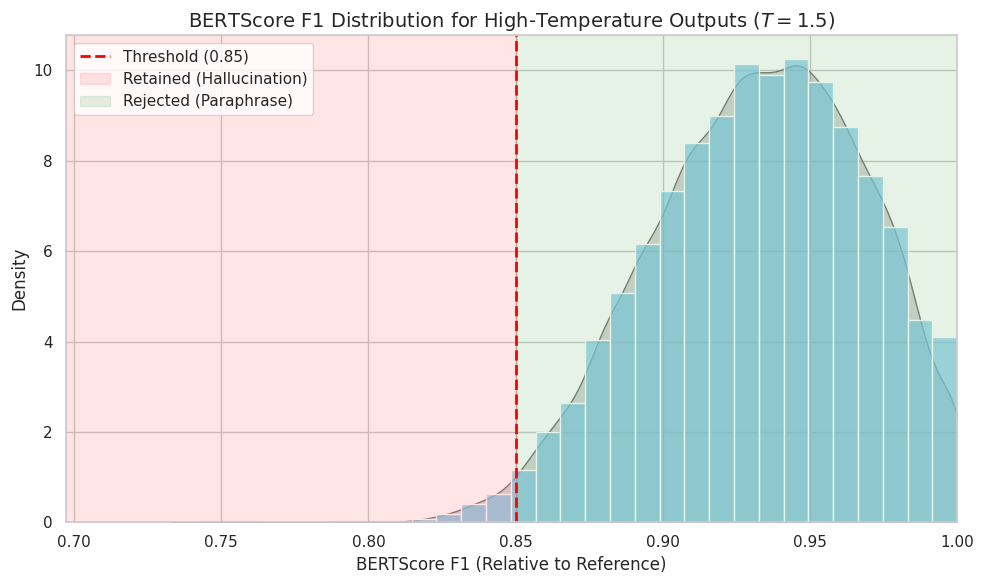

In [ ]:
import pandas as pd
import random
from tqdm import tqdm
from bert_score import score as calculate_bertscore

# Initialize
hallucinator = HallucinationGenerator(
    reference_sentences=df_sample['english'].tolist(),
    model=model,
    tokenizer=tokenizer,
    device=device
)

data_rows = []
temp_generation_queue = [] 

print("Phase 1: Planning dataset and applying base CPU mutations...")

# 4 hallucinations per row
num_hallucinations_per_row = 4

for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    sinhala_src = row['sinhala']
    english_gt = row['english'] 
    
    # --- A. Correct Sample ---
    data_rows.append({
        "sinhala": sinhala_src,
        "hypothesis": english_gt,       
        "reference": english_gt,        
        "label": 0,
        "method": "ground_truth",
        "needs_temp": False 
    })
    
    # --- B. Plan Negative Samples ---
    for _ in range(num_hallucinations_per_row):
        current_text = english_gt
        applied_labels = []
        needs_temp = False
        
        # STEP 1: BASE DECISION (80% Temp / 20% Atomic)
        if random.random() < 0.8:
            needs_temp = True
            applied_labels.append("temp")
            # Will be queued for the GPU later. Kept the text as english_gt for now.
        else:
            strategies, doc = hallucinator._detect_applicable_strategies(current_text)
            if strategies:
                func = random.choice(strategies)
                current_text = func(current_text, doc=doc)
                name = func.__name__.replace("hallucinate_", "").replace("_swap", "")
                applied_labels.append(name)
            else:
                needs_temp = True
                applied_labels.append("temp")

        # Record the plan
        row_plan = {
            "sinhala": sinhala_src,
            "hypothesis": current_text, # Will be updated later if needs_temp is True
            "reference": english_gt,
            "label": 1,
            "method": " + ".join(applied_labels),
            "needs_temp": needs_temp,
            "base_text_for_temp": english_gt 
        }
        data_rows.append(row_plan)

# Create a working DataFrame from the plan
working_df = pd.DataFrame(data_rows)


print("\nPhase 2: Executing Batched GPU Generation & BERTScore Filtering...")

temp_mask = working_df['needs_temp'] == True
texts_to_generate = working_df.loc[temp_mask, 'base_text_for_temp'].tolist()
references = working_df.loc[temp_mask, 'reference'].tolist()

if texts_to_generate:
    # 1. Generate Hypotheses
    generated_hypotheses = hallucinator.hallucinate_high_temp_batch(
        texts_to_generate, 
        temperature=1.5, 
        batch_size=32
    )
    
    # 2. Compute BERTScore (roberta-large)
    print("Calculating BERTScores...")
    _, _, f1_tensor = calculate_bertscore(
        generated_hypotheses, 
        references, 
        model_type="roberta-large", 
        lang="en", 
        device=device,
        verbose=False
    )
    f1_scores = f1_tensor.tolist()

    # 3. Generate the Chart
    plot_bertscore_distribution(f1_scores, threshold=0.85)

    # 4. Apply Filter Logic
    final_temp_results = []
    for hypo, f1 in zip(generated_hypotheses, f1_scores):
        if f1 < 0.85:
            # Below 0.85 = Genuine semantic divergence (Hallucination)
            final_temp_results.append((hypo, "temp"))
        else:
            # Above 0.85 = Likely a paraphrase (Rejected)
            final_temp_results.append((None, "rejected_temp"))
            
    # Map back to dataframe
    hypos, methods = zip(*final_temp_results)
    working_df.loc[temp_mask, 'hypothesis'] = list(hypos)
    working_df.loc[temp_mask, 'method'] = list(methods)

print(f"Filtering complete. {working_df['method'].value_counts().get('rejected_temp', 0)} samples sent to fallback.")

# --- FALLBACKS & SECONDARY MUTATIONS ---
print("\nPhase 3: Processing Fallbacks and Secondary Mutations...")

final_rows = working_df.to_dict('records')

for row in tqdm(final_rows):
    if row['label'] == 0: continue # Skip ground truth rows
    
    # --- A. Handle Rejected Temp Fallbacks ---
    # If temp was rejected, trying a  deterministic corruption
    if row['method'] == "rejected_temp":
        strategies, doc = hallucinator._detect_applicable_strategies(row['reference'])
        if strategies:
            func = random.choice(strategies)
            row['hypothesis'] = func(row['reference'], doc=doc)
            row['method'] = func.__name__.replace("hallucinate_", "").replace("_swap", "")
        else:
            # No atomic method applicable -> Revert to faithful
            row['hypothesis'] = row['reference']
            row['label'] = 0
            row['method'] = "ground_truth (temp_rejected_no_fallback)"
            continue # Skip secondary mutation for faithful rows

    # --- B. Secondary Mutation (80% chance) ---
    # Only if the row is still a hallucination and hasn't just been turned into faithful
    if row['label'] == 1 and random.random() < 0.8:
        current_text = row['hypothesis']
        strategies, doc = hallucinator._detect_applicable_strategies(current_text)
        
        # Filter strategies to avoid repeating the base method
        existing_labels = row['method'].split(" + ")
        valid_strategies = [f for f in strategies if f.__name__.replace("hallucinate_", "").replace("_swap", "") not in existing_labels]
        
        if valid_strategies:
            func = random.choice(valid_strategies)
            new_text = func(current_text, doc=doc)
            if new_text != current_text:
                row['hypothesis'] = new_text
                name = func.__name__.replace("hallucinate_", "").replace("_swap", "")
                row['method'] += f" + {name}"

    # --- C. Final Safety Check ---
    if row['hypothesis'] == row['reference']:
        row['label'] = 0
        row['method'] = "ground_truth (fallback_failed)"

synthetic_df = pd.DataFrame(final_rows)
synthetic_df = synthetic_df.drop(columns=['needs_temp', 'base_text_for_temp'], errors='ignore')
synthetic_df = synthetic_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDataset Generation Complete with BERTScore filtering!")
print("Method Distribution:\n", synthetic_df['method'].value_counts())
display(synthetic_df.head())

## 9. Save Full Dataset

Save the complete generated dataset — prior to grammar filtering — to CSV. This intermediate file preserves all generated hypotheses and can be used to inspect the raw output of the generation pipeline before the grammar validity filter is applied.


In [10]:
synthetic_df.to_csv("synthetic_hallucinations_probabilistic.csv")

## 10. Balance Dataset & Export

Downsample the majority class to produce a perfectly balanced dataset (50% faithful, 50% hallucinated). Both the full unbalanced and the class-balanced CSVs are saved separately so that downstream experiments can choose which distribution to train on.


In [ ]:
# DOWNLOAD DATASETS

import pandas as pd
from IPython.display import FileLink, display as ipy_display


full_path = "synthetic_hallucinations_probabilistic.csv"
print(f"Full dataset: {len(synthetic_df)} rows")
print(f"  Class balance:\n{synthetic_df['label'].value_counts().to_string()}\n")

df_faithful      = synthetic_df[synthetic_df['label'] == 0]
df_hallucination = synthetic_df[synthetic_df['label'] == 1]

# Match minority class size
min_count = min(len(df_faithful), len(df_hallucination))
df_balanced = pd.concat([
    df_faithful.sample(n=min_count, random_state=42),
    df_hallucination.sample(n=min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

balanced_path = "synthetic_hallucinations_probabilistic_balanced.csv"
df_balanced.to_csv(balanced_path, index=False)
print(f"Balanced dataset: {len(df_balanced)} rows")
print(f"  Class balance:\n{df_balanced['label'].value_counts().to_string()}\n")

try:
    import shutil, os
    kaggle_out = "/kaggle/working"
    if os.path.exists(kaggle_out):
        shutil.copy(full_path,     os.path.join(kaggle_out, full_path))
        shutil.copy(balanced_path, os.path.join(kaggle_out, balanced_path))
        print("Files copied to /kaggle/working — visible in the Kaggle Output panel.")
    else:
        raise FileNotFoundError("Not on Kaggle")
except Exception:
    try:
        from google.colab import files
        print("Triggering Colab downloads...")
        files.download(full_path)
        files.download(balanced_path)
    except ImportError:
        print("Local Jupyter — click to download:")
        ipy_display(FileLink(full_path))
        ipy_display(FileLink(balanced_path))

print("\nDone! Both CSVs are ready.")


Full dataset: 37500 rows
  Class balance:
label
1    27096
0    10404

Balanced dataset: 20808 rows
  Class balance:
label
0    10404
1    10404

Triggering Colab downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Both CSVs are ready.


## 11. Grammar Validity Filter

Apply a post-hoc grammar check using LanguageTool across all hallucinated hypothesis rows. Rows with more than two meaningful grammar errors — excluding punctuation, typography, whitespace, and casing categories — are reverted to faithful ground-truth labels and annotated with the method tag `ground_truth (grammar_rejected)`.

This filter ensures the detector is trained to recognise semantic divergence rather than surface-level syntactic breakage. A hallucination that reads as broken English teaches the model a shortcut; one that reads as fluent but wrong forces it to learn meaning-level signals.


In [12]:
!pip install -q pandarallel

  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
from tqdm.auto import tqdm
import language_tool_python

# Enable tqdm for pandas apply
tqdm.pandas(desc="Grammar Check Progress")

print("Starting local LanguageTool server (just once!)...")
# Initialize the Java server exactly ONCE outside the function
tool = language_tool_python.LanguageTool("en-US")
IGNORE_CATEGORIES = {"PUNCTUATION", "TYPOGRAPHY", "WHITESPACE", "CASING"}

def check_grammar_stable(text):
    if not isinstance(text, str) or not text.strip():
        return False
        
    try:
        matches = tool.check(text)
        significant_errors = [m for m in matches if m.category.upper() not in IGNORE_CATEGORIES]
        return len(significant_errors) <= 2
    except Exception:
        return False

# Only checking labels that are currently labeled as hallucinations
print("Running stable grammar check on generated hypotheses...")

synthetic_df = pd.read_csv("/kaggle/input/datasets/navamobeysekara/final-synthetic/synthetic_hallucinations_exhaustive(2).csv")
mask = synthetic_df['label'] == 1

valid_grammar_mask = synthetic_df.loc[mask, 'hypothesis'].progress_apply(check_grammar_stable)

# Update the dataset based on the results
invalid_indices = valid_grammar_mask[~valid_grammar_mask].index

# Revert those failed rows back to faithful ground truth
synthetic_df.loc[invalid_indices, 'label'] = 0
synthetic_df.loc[invalid_indices, 'hypothesis'] = synthetic_df.loc[invalid_indices, 'reference']
synthetic_df.loc[invalid_indices, 'method'] = "ground_truth (grammar_rejected)"

tool.close()

print(f"Grammar check complete! Rejected {len(invalid_indices)} grammatically broken rows.")

Starting local LanguageTool server (just once!)...
Running stable grammar check on generated hypotheses...


Grammar Check Progress:   0%|          | 0/24996 [00:00<?, ?it/s]

Grammar check complete! Rejected 79 grammatically broken rows.


## 12. Save Grammar-Checked Dataset

Save the final grammar-validated dataset to the output directory. This is the canonical training file used by all downstream detector notebooks.


In [ ]:
output_file_path = "/kaggle/working/synthetic_hallucinations_grammar_checked.csv"

synthetic_df.to_csv(output_file_path, index=False)

print(f"Successfully saved the updated dataset to: {output_file_path}")

Successfully saved the updated dataset to: /kaggle/working/synthetic_hallucinations_grammar_checked.csv
